### **Pixel-to-Metre Sequence Processor**

#### **1. Imports and Setup**

In [1]:
import os
import cv2
import numpy as np
import torch
import PIL.Image
from ultralytics import YOLO
from IPython.display import Video, display

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

#### **2. Configuration**

Define your constants here. We will process 60 frames starting from a specific index.

In [2]:
# Configuration
YOLO_MARKER_MODEL_PATH = "runs/detect/runs/detect/marker_detector/weights/best.pt"
YOLO_PERSON_MODEL_PATH = "yolov8s.pt" # Standard person detection
FRAMES_DIR = "frames/under/Bottom_Freestyle_P035/"
START_FRAME_IDX = 0
NUM_FRAMES = -1  # Set to -1 to process all frames
FPS = 60  # Frames per second for the output video

MARKER_REAL_DIST_M = 2.5
YOLO_CONF = 0.3 # down from à.è
OUTPUT_VIDEO_PATH = "output/ego_motion_freestyle_p035.mp4"

# Load Models
marker_model = YOLO(YOLO_MARKER_MODEL_PATH)
person_model = YOLO(YOLO_PERSON_MODEL_PATH)

# Transformers for ViTPose
from transformers import AutoProcessor, VitPoseForPoseEstimation
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

try:
    pose_model_name = "usyd-community/vitpose-plus-large"
    pose_image_processor = AutoProcessor.from_pretrained(pose_model_name)
    pose_model = VitPoseForPoseEstimation.from_pretrained(pose_model_name, device_map=device)
    print("Transformers ViTPose Model Loaded!")
except Exception as e:
    print(f"Error loading ViTPose: {e}")

Using device: cuda


The image processor of type `VitPoseImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/691 [00:00<?, ?it/s]

Transformers ViTPose Model Loaded!


#### **3. Processing Loop**

This script iterates through the frames, performs detection, calculates distances, draws the visualization, and writes to a video file.

In [3]:
def get_centroid(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def put_text_bg(img, text, pos, color, scale=0.7, alpha=0.5):
    """Draws text with a semi-transparent black background, matching matplotlib."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    thickness = 2
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    x, y = pos
    x1, y1 = int(max(0, x-5)), int(max(0, y-th-5))
    x2, y2 = int(min(img.shape[1], x+tw+5)), int(min(img.shape[0], y+baseline+5))
    
    if x2 > x1 and y2 > y1:
        overlay = img[y1:y2, x1:x2].copy()
        cv2.rectangle(overlay, (0, 0), (x2-x1, y2-y1), (0, 0, 0), -1)
        cv2.addWeighted(overlay, alpha, img[y1:y2, x1:x2], 1 - alpha, 0, img[y1:y2, x1:x2])
        
    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)

# Initialize Video Writer
# Note: 'mp4v' is widely supported; 'avc1' is better for browser playback if available
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = None
target_h, target_w = 0, 0

MARKER_HEIGHT_M = 0.6  # From demo
tracking_records = []

frame_range = range(NUM_FRAMES) if NUM_FRAMES > 0 else range(START_FRAME_IDX, START_FRAME_IDX + len(os.listdir(FRAMES_DIR)))
# frame_paths either in format 00001.jpg or frame_00001.jpg because some were extracted manually before i made the bulk extractor
suffix = "frame_" if os.path.exists(os.path.join(FRAMES_DIR, f"frame_{START_FRAME_IDX:05d}.jpg")) else ""
frame_paths = [os.path.join(FRAMES_DIR, f"{suffix}{START_FRAME_IDX + i:05d}.jpg") for i in frame_range]


# Optimisation (4): Process Inference in Batches
BATCH_SIZE = 16  
print(f"Processing {len(frame_paths)} frames using batch size of {BATCH_SIZE}...")

# 1. Initialize Global State
global_camera_x = 0.0
prev_markers_x = []
prev_px_per_m = None
prev_delta_x = 0.0

for b in range(0, len(frame_paths), BATCH_SIZE):
    batch_paths = frame_paths[b:b+BATCH_SIZE]
    batch_frames = []
    
    # Load batch
    for p in batch_paths:
        f = cv2.imread(p)
        if f is not None:
            batch_frames.append(f)
        else:
            print(f"Warning: Could not load {p}")
            
    if not batch_frames:
        continue

    img_h, img_w = batch_frames[0].shape[:2]

    # Run batched YOLO detection (utilises GPU more efficiently)
    marker_results = marker_model.predict(batch_frames, conf=YOLO_CONF, verbose=False)
    # Using a much lower confidence for the standard person model so it catches the swimmer
    person_results = person_model.predict(batch_frames, conf=0.15, verbose=False)

    for idx_in_batch, (frame, m_res, p_res) in enumerate(zip(batch_frames, marker_results, person_results)):
        frame_idx = START_FRAME_IDX + b + idx_in_batch
        
        swimmer_centroid = None
        swimmer_lwrist = None
        swimmer_rwrist = None
        swimmer_hbox     = None
        swimmer_kpts     = None
        swimmer_kpt_scores = None
        _box_records     = []
        
        current_marker_detections = []

        # 1. Process markers
        for box in m_res.boxes:
            cls            = int(box.cls)
            conf           = float(box.conf)
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cx, cy         = (x1 + x2) / 2, y2  # Use BOTTOM-CENTER as anchor point
            if cls == 0:
                _box_records.append((cls, conf, x1, y1, x2, y2, cx, cy))
                current_marker_detections.append({"pt": (cx, cy), "box": (x1, y1, x2, y2, cx, cy)})

        # 2. Process person + ViTPose (Hips Centroid)
        largest_area = -1.0
        person_box = None
        for box in p_res.boxes:
            cls = int(box.cls)
            conf = float(box.conf)
            if cls == 0 and conf > 0.15: # COCO person class
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                area = (x2 - x1) * (y2 - y1)
                if area > largest_area:
                    largest_area = area
                    person_box = [x1, y1, x2, y2]

        if person_box is not None:
            x1, y1, x2, y2 = [int(v) for v in person_box]
            swimmer_hbox = (x1, y1, x2, y2)
            
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            vitpose_boxes = np.array([[x1, y1, bbox_w, bbox_h]])
            
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = PIL.Image.fromarray(img_rgb)
            inputs = pose_image_processor(pil_img, boxes=[vitpose_boxes], return_tensors="pt").to(device)
            
            if pose_model.config.backbone_config.num_experts > 1:
                inputs["dataset_index"] = torch.tensor([0] * len(inputs["pixel_values"])).to(device)

            with torch.no_grad():
                outputs = pose_model(**inputs)
            
            pose_results = pose_image_processor.post_process_pose_estimation(outputs, boxes=[vitpose_boxes])
            
            if len(pose_results) > 0 and len(pose_results[0]) > 0:
                person_pose = pose_results[0][0]
                kpts = person_pose["keypoints"].cpu().numpy()
                scores = person_pose["scores"].cpu().numpy()
                
                swimmer_kpts = kpts
                swimmer_kpt_scores = scores
                
                # Check for hips (11 and 12)
                if len(kpts) > 12 and scores[11] > 0.1 and scores[12] > 0.1:
                    lh = kpts[11]
                    rh = kpts[12]
                    swimmer_centroid = (int((lh[0] + rh[0]) / 2), int((lh[1] + rh[1]) / 2))
                
                # Check for wrists (9: left wrist, 10: right wrist)
                # Apply confidence threshold (e.g. 0.3)
                if len(kpts) > 10:
                    if scores[9] > 0.3:
                        swimmer_lwrist = tuple(kpts[9])
                    if scores[10] > 0.3:
                        swimmer_rwrist = tuple(kpts[10])

        # -----------------------------
        # EGO-MOTION ASSUMPTION LOGIC
        # -----------------------------
        out_frame = frame.copy()
        
        # Draw Swimmer Box and ViTPose Keypoints
        if swimmer_hbox is not None:
            sx1, sy1, sx2, sy2 = swimmer_hbox
            cv2.rectangle(out_frame, (sx1, sy1), (sx2, sy2), (255, 255, 0), 5)
            
        if swimmer_kpts is not None and swimmer_kpt_scores is not None:
            for i, (kp, score) in enumerate(zip(swimmer_kpts, swimmer_kpt_scores)):
                if score > 0.1:
                    color = (0, 0, 255)
                    if i in [9, 10]: # Wrists
                        color = (0, 255, 0) if score > 0.3 else (0, 100, 0)
                    cv2.circle(out_frame, (int(kp[0]), int(kp[1])), 6, color, -1)

        # 2. Calculate Frame-to-Frame Displacement
        current_markers_x = [m["pt"][0] for m in current_marker_detections]
        delta_x = 0.0
        
        if prev_markers_x and current_markers_x:
            valid_deltas = []
            for cx in current_markers_x:
                diffs = [cx - px for px in prev_markers_x]
                abs_diffs = [abs(d) for d in diffs]
                min_idx = np.argmin(abs_diffs)
                if abs_diffs[min_idx] < 50.0:  # Threshold of 50 pixels
                    valid_deltas.append(diffs[min_idx])
            
            if valid_deltas:
                delta_x = float(np.median(valid_deltas))
            else:
                delta_x = prev_delta_x
        elif prev_markers_x and not current_markers_x:
            # Linear projection if markers lost
            delta_x = prev_delta_x
            
        # 3. Update Global Camera Offset
        global_camera_x -= delta_x
        prev_delta_x = delta_x

        # 4 & 5. Apply Scale (using outer markers)
        # Sort markers left-to-right
        sorted_markers = sorted(current_marker_detections, key=lambda m: m["pt"][0])
        px_per_m = prev_px_per_m if prev_px_per_m is not None else 1.0
        
        if len(sorted_markers) >= 2:
            A_pt = np.array(sorted_markers[0]["pt"])
            B_pt = np.array(sorted_markers[-1]["pt"])
            
            dist_px = np.linalg.norm(B_pt - A_pt)
            num_intervals = len(sorted_markers) - 1
            physical_dist = num_intervals * MARKER_REAL_DIST_M
            
            if physical_dist > 0:
                px_per_m = dist_px / physical_dist
                prev_px_per_m = px_per_m
                
            # Draw baseline
            A_px = tuple(A_pt.astype(int))
            B_px = tuple(B_pt.astype(int))
            cv2.line(out_frame, A_px, B_px, (255, 0, 255), 2, cv2.LINE_AA)

        # Draw markers on output frame
        for md in current_marker_detections:
            pt_px = tuple(np.array(md["pt"]).astype(int))
            cv2.circle(out_frame, pt_px, 6, (0, 255, 0), -1)

        # Calculate Swimmer and Wrist Global Positions
        if swimmer_centroid is not None:
            swimmer_pixel_x = swimmer_centroid[0]
            virtual_x = swimmer_pixel_x + global_camera_x
            global_pos_m = virtual_x / px_per_m if px_per_m > 0 else 0.0
            
            lwrist_pos_m = np.nan
            rwrist_pos_m = np.nan
            
            # Project swimmer and wrists onto baseline if >= 2 markers
            if len(sorted_markers) >= 2:
                AB = B_pt - A_pt
                AB_len = np.linalg.norm(AB)
                if AB_len > 0:
                    AB_unit = AB / AB_len
                    
                    # Project Centroid
                    S_pt = np.array(swimmer_centroid)
                    t_cent = np.dot(S_pt - A_pt, AB_unit)
                    proj_S = A_pt + t_cent * AB_unit
                    proj_px = tuple(proj_S.astype(int))
                    S_px = tuple(S_pt.astype(int))
                    cv2.line(out_frame, S_px, proj_px, (0, 255, 255), 2, cv2.LINE_AA)
                    cv2.circle(out_frame, proj_px, 6, (0, 255, 255), -1, cv2.LINE_AA)
                    
                    # Project Left Wrist
                    if swimmer_lwrist is not None:
                        LW_pt = np.array(swimmer_lwrist)
                        virtual_lw_x = LW_pt[0] + global_camera_x
                        lwrist_pos_m = virtual_lw_x / px_per_m if px_per_m > 0 else 0.0
                        
                        t_lw = np.dot(LW_pt - A_pt, AB_unit)
                        proj_LW = A_pt + t_lw * AB_unit
                        proj_lw_px = tuple(proj_LW.astype(int))
                        cv2.line(out_frame, tuple(LW_pt.astype(int)), proj_lw_px, (0, 255, 0), 1, cv2.LINE_AA)
                        
                    # Project Right Wrist
                    if swimmer_rwrist is not None:
                        RW_pt = np.array(swimmer_rwrist)
                        virtual_rw_x = RW_pt[0] + global_camera_x
                        rwrist_pos_m = virtual_rw_x / px_per_m if px_per_m > 0 else 0.0
                        
                        t_rw = np.dot(RW_pt - A_pt, AB_unit)
                        proj_RW = A_pt + t_rw * AB_unit
                        proj_rw_px = tuple(proj_RW.astype(int))
                        cv2.line(out_frame, tuple(RW_pt.astype(int)), proj_rw_px, (0, 255, 0), 1, cv2.LINE_AA)
            else:
                # If no baseline, just use raw X scaling
                if swimmer_lwrist is not None:
                    lwrist_pos_m = (swimmer_lwrist[0] + global_camera_x) / px_per_m if px_per_m > 0 else 0.0
                if swimmer_rwrist is not None:
                    rwrist_pos_m = (swimmer_rwrist[0] + global_camera_x) / px_per_m if px_per_m > 0 else 0.0
            
            tracking_records.append({
                "frame_idx": frame_idx,
                "time_s": (b + idx_in_batch) / FPS,
                "pos_m": float(global_pos_m),
                "lwrist_pos_m": float(lwrist_pos_m) if not np.isnan(lwrist_pos_m) else None,
                "rwrist_pos_m": float(rwrist_pos_m) if not np.isnan(rwrist_pos_m) else None,
                "px_per_m": float(px_per_m),
                "selection_mode": "auto"
            })
            
            # Visualize Swimmer Data
            S_px = tuple(np.array(swimmer_centroid).astype(int))
            CYAN = (255, 191, 0)
            ORANGE = (0, 165, 255)
            YELLOW = (0, 255, 255)
            
            cv2.circle(out_frame, S_px, 8, CYAN, -1, cv2.LINE_AA)
            put_text_bg(out_frame, "Swimmer", (S_px[0] + 8, S_px[1] - 15), CYAN)
            
            bar_len = int(px_per_m)
            bar_margin = 40
            bar_x1, bar_y = bar_margin, img_h - bar_margin
            bar_x2 = bar_x1 + bar_len
            
            if bar_len > 0:
                tip_len = 15.0 / bar_len
                cv2.arrowedLine(out_frame, (bar_x1, bar_y), (bar_x2, bar_y), YELLOW, 3, tipLength=tip_len)
                cv2.arrowedLine(out_frame, (bar_x2, bar_y), (bar_x1, bar_y), YELLOW, 3, tipLength=tip_len)
                put_text_bg(out_frame, "1 m", (bar_x1 + bar_len//2 - 20, bar_y - 15), YELLOW)

            put_text_bg(out_frame, f"Scale: {px_per_m:.1f} px/m", (40, 40), YELLOW, scale=0.9)
            put_text_bg(out_frame, f"Global Pos: {global_pos_m:.2f} m", (40, 80), ORANGE, scale=0.9)

        # 6. State Update
        prev_markers_x = current_markers_x

        if out_writer is None:
            target_h, target_w, _ = out_frame.shape
            out_writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, (target_w, target_h))

        h, w, _ = out_frame.shape
        if w != target_w or h != target_h:
            out_frame = cv2.resize(out_frame, (target_w, target_h))

        out_writer.write(out_frame)

if out_writer:
    out_writer.release()

print(f"Done! Video saved to {OUTPUT_VIDEO_PATH}")

Processing 4291 frames using batch size of 16...
Done! Video saved to output/ego_motion_freestyle_p035.mp4


Removed 1385 significant deviations; kept 2581 records.


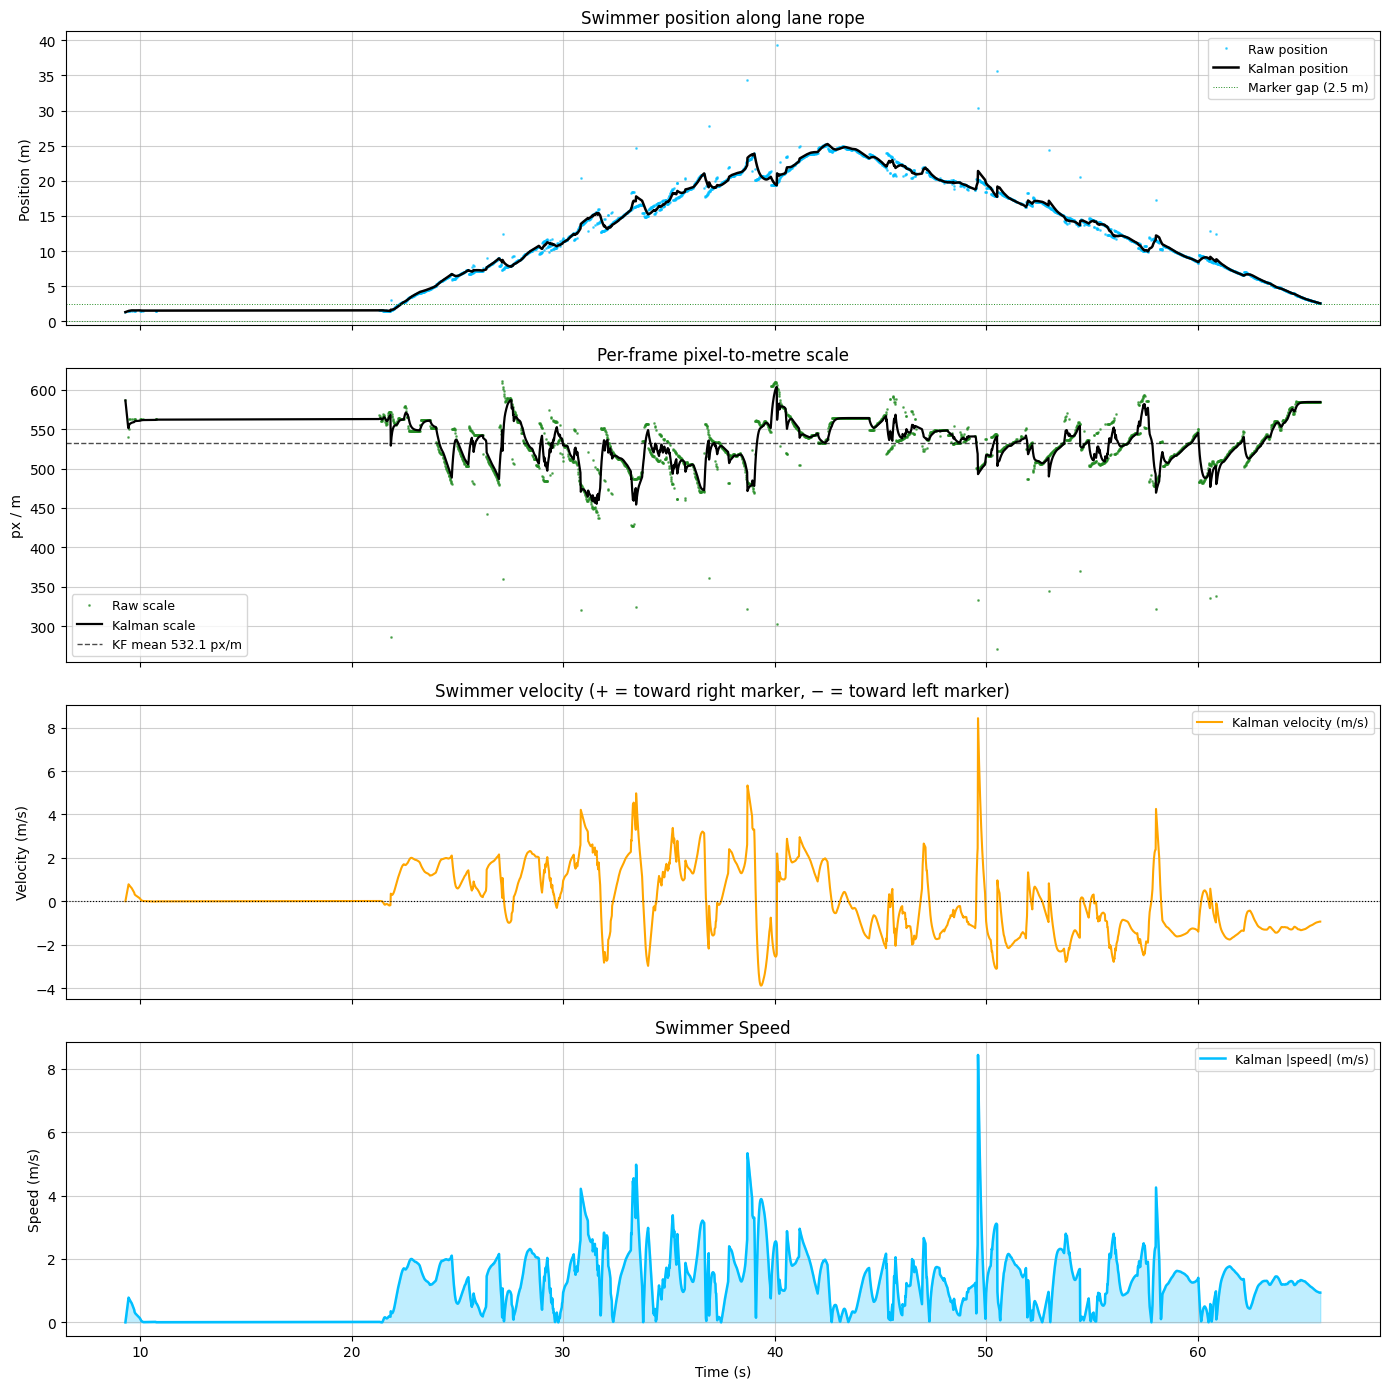

Kalman filter summary
  Position std raw / KF : 6.7322 / 6.7060 m
  Scale std raw / KF    : 33.3638 / 26.6689 px/m
  Peak |velocity|       : 8.4362 m/s  (30.370 km/h)
  Mean |velocity|       : 1.3923 m/s  (5.012 km/h)


In [8]:
import matplotlib.pyplot as plt

# Extract valid tracking records
valid = [r for r in tracking_records if r["pos_m"] is not None]


if not valid:
    print("No valid tracking records found to plot.")
else:
    # remove outliers from recorded data
    if len(valid) >= 5:
        pos_vals = np.array([v["pos_m"] for v in valid], dtype=float)
        scale_vals = np.array([v["px_per_m"] for v in valid], dtype=float)

        def _mad_inlier_mask(x, z_thresh=3.5):
            med = np.median(x)
            mad = np.median(np.abs(x - med))
            if mad < 1e-12:
                return np.ones_like(x, dtype=bool)
            robust_z = 0.6745 * (x - med) / mad
            return np.abs(robust_z) <= z_thresh

        pos_mask = _mad_inlier_mask(pos_vals, z_thresh=3.5)
        scale_mask = _mad_inlier_mask(scale_vals, z_thresh=3.5)

        # Optional temporal jump filter on position
        dpos = np.r_[0.0, np.abs(np.diff(pos_vals))]
        jump_thr = np.median(dpos) + 4.0 * np.std(dpos)
        jump_mask = dpos <= jump_thr if np.isfinite(jump_thr) and jump_thr > 0 else np.ones_like(dpos, dtype=bool)

        keep_mask = pos_mask & scale_mask & jump_mask
        removed = int((~keep_mask).sum())
        valid = [v for v, keep in zip(valid, keep_mask) if keep]

        print(f"Removed {removed} significant deviations; kept {len(valid)} records.")
    
    times      = np.array([v["time_s"] for v in valid], dtype=float)
    pos_raw    = np.array([v["pos_m"] for v in valid], dtype=float)
    scales_raw = np.array([v["px_per_m"] for v in valid], dtype=float)
    mode_seq   = [v["selection_mode"] for v in valid]

    # Use a simpler mapping for noise scale since we are only using "auto" here
    _MODE_NOISE_SCALE = {"auto": 1.0}

    def kalman_filter_pos_vel(times_s, pos_meas, mode_names, accel_var=3.0, meas_var=0.015):
        n = len(pos_meas)
        pos_est = np.zeros(n, dtype=float)
        vel_est = np.zeros(n, dtype=float)
        if n == 0:
            return pos_est, vel_est

        x = np.array([pos_meas[0], 0.0], dtype=float)
        P = np.diag([0.10**2, 1.00**2]).astype(float)
        pos_est[0], vel_est[0] = x

        for i in range(1, n):
            dt = max(times_s[i] - times_s[i - 1], 1.0 / FPS)
            F = np.array([[1.0, dt], [0.0, 1.0]], dtype=float)
            Q = accel_var * np.array([
                [dt**4 / 4.0, dt**3 / 2.0],
                [dt**3 / 2.0, dt**2],
            ], dtype=float)

            x = F @ x
            P = F @ P @ F.T + Q

            H = np.array([[1.0, 0.0]], dtype=float)
            R = np.array([[meas_var * _MODE_NOISE_SCALE.get(mode_names[i], 4.0)]], dtype=float)
            z = np.array([[pos_meas[i]]], dtype=float)

            y = z - H @ x.reshape(-1, 1)
            s_cov = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(s_cov)
            x = x + (K @ y).ravel()
            P = (np.eye(2) - K @ H) @ P

            pos_est[i], vel_est[i] = x

        return pos_est, vel_est

    def kalman_filter_scale(scale_meas, mode_names, process_var=0.20, meas_var=9.0):
        n = len(scale_meas)
        scale_est = np.zeros(n, dtype=float)
        if n == 0:
            return scale_est

        x = float(scale_meas[0])
        P = 25.0
        scale_est[0] = x

        for i in range(1, n):
            P = P + process_var
            R = meas_var * _MODE_NOISE_SCALE.get(mode_names[i], 4.0)
            K = P / (P + R)
            x = x + K * (scale_meas[i] - x)
            P = (1.0 - K) * P
            scale_est[i] = x

        return scale_est

    pos_kf, vel_kf = kalman_filter_pos_vel(times, pos_raw, mode_seq)
    scale_kf       = kalman_filter_scale(scales_raw, mode_seq)
    spd_kf         = np.abs(vel_kf)

    with plt.style.context("default"):
        fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

        # [0] Raw + filtered position
        axes[0].plot(times, pos_raw, ".", markersize=2, color="deepskyblue",
                     alpha=0.60, label="Raw position")
        axes[0].plot(times, pos_kf, "-", linewidth=1.8, color="black",
                     label="Kalman position")
        axes[0].axhline(0, color="forestgreen", linewidth=0.7, linestyle=":")
        axes[0].axhline(MARKER_REAL_DIST_M, color="forestgreen", linewidth=0.7, linestyle=":",
                        label=f"Marker gap ({MARKER_REAL_DIST_M} m)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer position along lane rope")
        axes[0].legend(fontsize=9)
        axes[0].grid(alpha=0.6)

        # [1] Raw + filtered scale
        axes[1].plot(times, scales_raw, ".", markersize=2, color="forestgreen", alpha=0.60,
                     label="Raw scale")
        axes[1].plot(times, scale_kf, "-", linewidth=1.6, color="black",
                     label="Kalman scale")
        axes[1].axhline(np.mean(scale_kf), color="black", linewidth=1.0, linestyle="--",
                        alpha=0.7, label=f"KF mean {np.mean(scale_kf):.1f} px/m")
        axes[1].set_ylabel("px / m")
        axes[1].set_title("Per-frame pixel-to-metre scale")
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.6)

        # [2] Signed velocity
        axes[2].plot(times, vel_kf, "-", linewidth=1.5, color="orange",
                     label="Kalman velocity (m/s)")
        axes[2].axhline(0, color="black", linewidth=0.8, linestyle=":")
        axes[2].set_ylabel("Velocity (m/s)")
        axes[2].set_title("Swimmer velocity (+ = toward right marker, − = toward left marker)")
        axes[2].legend(fontsize=9)
        axes[2].grid(alpha=0.6)

        # [3] Speed magnitude
        axes[3].fill_between(times, spd_kf, alpha=0.25, color="deepskyblue")
        axes[3].plot(times, spd_kf, "-", linewidth=1.8, color="deepskyblue",
                     label="Kalman |speed| (m/s)")
        axes[3].set_ylabel("Speed (m/s)")
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Swimmer Speed")
        axes[3].legend(fontsize=9)
        axes[3].grid(alpha=0.6)

        plt.tight_layout()
        plt.show()

    print("Kalman filter summary")
    print(f"  Position std raw / KF : {np.std(pos_raw):.4f} / {np.std(pos_kf):.4f} m")
    print(f"  Scale std raw / KF    : {np.std(scales_raw):.4f} / {np.std(scale_kf):.4f} px/m")
    print(f"  Peak |velocity|       : {spd_kf.max():.4f} m/s  ({spd_kf.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity|       : {spd_kf.mean():.4f} m/s  ({spd_kf.mean() * 3.6:.3f} km/h)")

Keeping 2571 samples, dropped 10 outliers with |velocity| > 5.0 m/s.


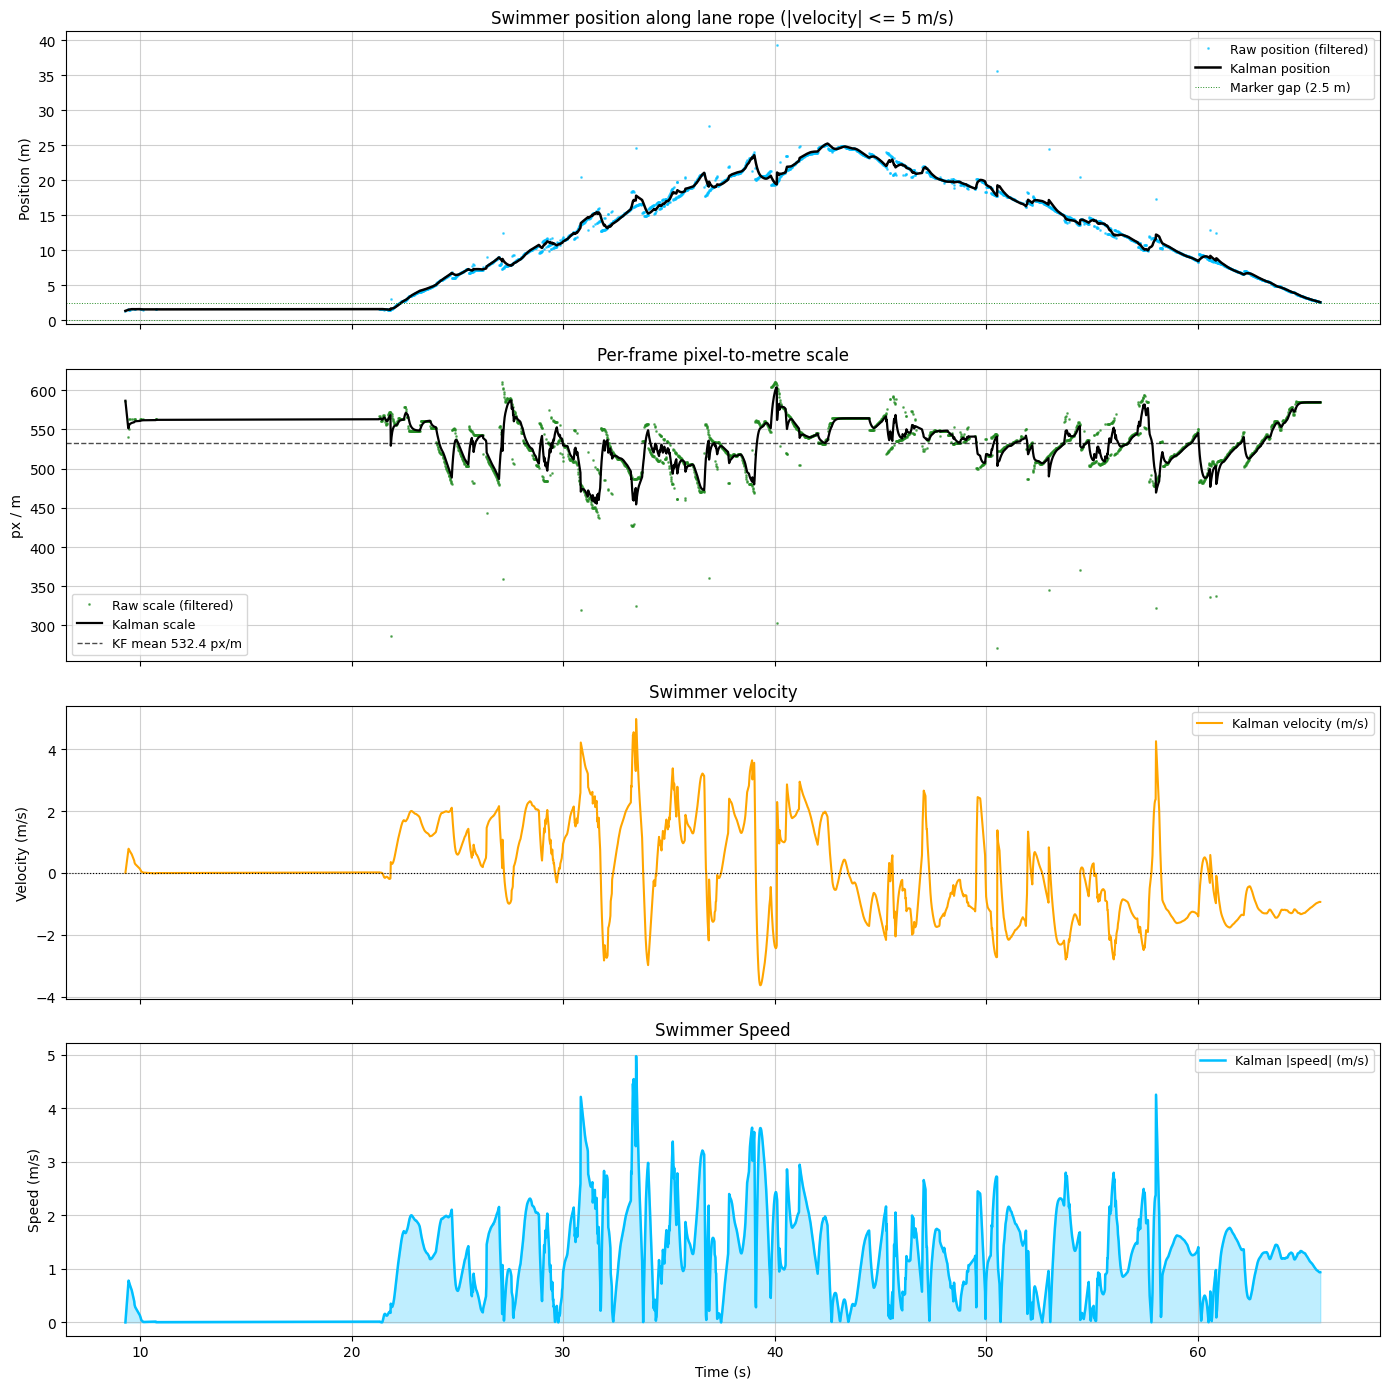

Filtered summary
  Peak |velocity| : 4.9736 m/s  (17.905 km/h)
  Mean |velocity| : 1.3548 m/s  (4.877 km/h)


In [9]:
# Filter out outliers based on velocity threshold
VEL_MAX = 5.0

if "times" not in locals() or "pos_raw" not in locals() or "scales_raw" not in locals() or "vel_kf" not in locals():
    print("Missing required variables (times, pos_raw, scales_raw, vel_kf).")
else:
    base_mask = np.isfinite(vel_kf) & (np.abs(vel_kf) <= VEL_MAX)
    kept = int(base_mask.sum())
    dropped = int((~base_mask).sum())
    print(f"Keeping {kept} samples, dropped {dropped} outliers with |velocity| > {VEL_MAX} m/s.")

    times_f = times[base_mask]
    pos_raw_f = pos_raw[base_mask]
    scales_raw_f = scales_raw[base_mask]

    if "mode_seq" in locals() and len(mode_seq) == len(base_mask):
        mode_seq_f = [m for m, k in zip(mode_seq, base_mask) if k]
    else:
        mode_seq_f = ["auto"] * len(times_f)

    # Recompute filtered Kalman tracks to keep plots consistent
    pos_kf_f, vel_kf_f = kalman_filter_pos_vel(times_f, pos_raw_f, mode_seq_f)
    scale_kf_f = kalman_filter_scale(scales_raw_f, mode_seq_f)
    spd_kf_f = np.abs(vel_kf_f)

    with plt.style.context("default"):
        fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

        # [0] Position
        axes[0].plot(times_f, pos_raw_f, ".", markersize=2, color="deepskyblue", alpha=0.60, label="Raw position (filtered)")
        axes[0].plot(times_f, pos_kf_f, "-", linewidth=1.8, color="black", label="Kalman position")
        axes[0].axhline(0, color="forestgreen", linewidth=0.7, linestyle=":")
        axes[0].axhline(MARKER_REAL_DIST_M, color="forestgreen", linewidth=0.7, linestyle=":",
                        label=f"Marker gap ({MARKER_REAL_DIST_M} m)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer position along lane rope (|velocity| <= 5 m/s)")
        axes[0].legend(fontsize=9)
        axes[0].grid(alpha=0.6)

        # [1] Scale
        axes[1].plot(times_f, scales_raw_f, ".", markersize=2, color="forestgreen", alpha=0.60, label="Raw scale (filtered)")
        axes[1].plot(times_f, scale_kf_f, "-", linewidth=1.6, color="black", label="Kalman scale")
        axes[1].axhline(np.mean(scale_kf_f), color="black", linewidth=1.0, linestyle="--", alpha=0.7,
                        label=f"KF mean {np.mean(scale_kf_f):.1f} px/m")
        axes[1].set_ylabel("px / m")
        axes[1].set_title("Per-frame pixel-to-metre scale")
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.6)

        # [2] Velocity
        axes[2].plot(times_f, vel_kf_f, "-", linewidth=1.5, color="orange", label="Kalman velocity (m/s)")
        axes[2].axhline(0, color="black", linewidth=0.8, linestyle=":")
        axes[2].set_ylabel("Velocity (m/s)")
        axes[2].set_title("Swimmer velocity")
        axes[2].legend(fontsize=9)
        axes[2].grid(alpha=0.6)

        # [3] Speed
        axes[3].fill_between(times_f, spd_kf_f, alpha=0.25, color="deepskyblue")
        axes[3].plot(times_f, spd_kf_f, "-", linewidth=1.8, color="deepskyblue", label="Kalman |speed| (m/s)")
        axes[3].set_ylabel("Speed (m/s)")
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Swimmer Speed")
        axes[3].legend(fontsize=9)
        axes[3].grid(alpha=0.6)

        plt.tight_layout()
        plt.show()

    print("Filtered summary")
    print(f"  Peak |velocity| : {spd_kf_f.max():.4f} m/s  ({spd_kf_f.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity| : {spd_kf_f.mean():.4f} m/s  ({spd_kf_f.mean() * 3.6:.3f} km/h)")

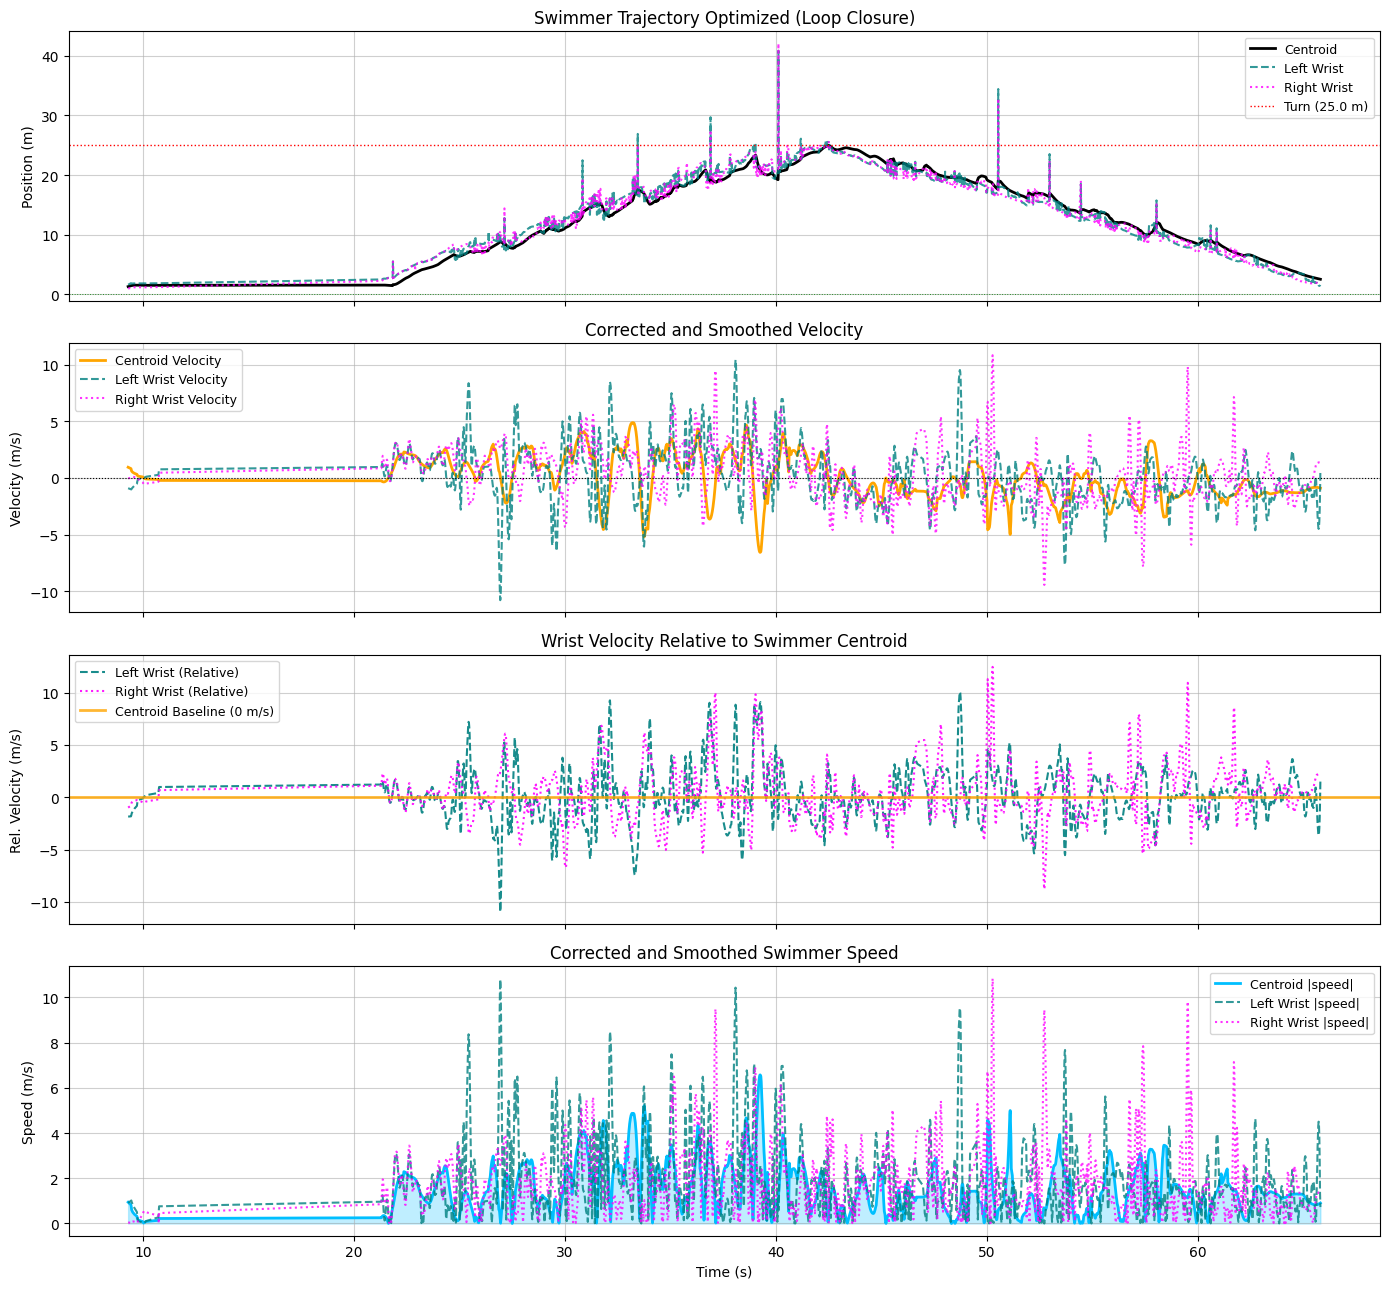

Post-processing summary (Loop Closure & Smoothing)
  Turn index            : 1273 (Time: 42.50s)
  Raw max position      : 25.23 m
  Applied scale out     : 0.9908
  Peak |velocity| (new) : 6.5704 m/s  (23.653 km/h)
  Mean |velocity| (new) : 1.5909 m/s  (5.727 km/h)


In [10]:
# --- 1D Global Trajectory Optimization (Loop Closure) ---
from scipy.signal import savgol_filter, medfilt
import pandas as pd

if "pos_kf_f" in locals() and len(pos_kf_f) > 0:
    # 1. Find the Inflection Point
    turn_idx = np.argmax(pos_kf_f)
    raw_max_pos = pos_kf_f[turn_idx]
    
    corrected_pos = np.copy(pos_kf_f)
    
    # Process Wrists: Extract raw arrays, fill NaNs via interpolation
    lwrist_raw = np.array([v.get("lwrist_pos_m", np.nan) for v in valid], dtype=float)[base_mask]
    rwrist_raw = np.array([v.get("rwrist_pos_m", np.nan) for v in valid], dtype=float)[base_mask]
    
    # Interpolate NaN gaps for wrists
    lwrist_series = pd.Series(lwrist_raw)
    rwrist_series = pd.Series(rwrist_raw)
    
    lwrist_interp = lwrist_series.interpolate(method='linear', limit_direction='both').to_numpy()
    rwrist_interp = rwrist_series.interpolate(method='linear', limit_direction='both').to_numpy()
    
    corrected_lwrist_pos = np.copy(lwrist_interp)
    corrected_rwrist_pos = np.copy(rwrist_interp)
    
    # 2. Outbound Lap Correction
    scale_out = 25.0 / raw_max_pos
    
    # Apply to centroid
    corrected_pos[:turn_idx+1] = pos_kf_f[:turn_idx+1] * scale_out
    # Apply SAME scaler to wrists
    corrected_lwrist_pos[:turn_idx+1] = lwrist_interp[:turn_idx+1] * scale_out
    corrected_rwrist_pos[:turn_idx+1] = rwrist_interp[:turn_idx+1] * scale_out
    
    # 3. Return Lap Correction
    if turn_idx < len(pos_kf_f) - 1:
        expected_end_pos = pos_kf_f[-1] * scale_out
        
        xp = [pos_kf_f[-1], pos_kf_f[turn_idx]]
        fp = [expected_end_pos, 25.0]
        
        corrected_pos[turn_idx:] = np.interp(pos_kf_f[turn_idx:], xp, fp)
        
        # Apply the exact same logic to wrists but mapping their specific points using the centroid bounds as reference
        # We need their values bounded properly to follow the return lap shift
        for i in range(turn_idx, len(corrected_pos)):
            ratio = (pos_kf_f[i] - pos_kf_f[-1]) / (pos_kf_f[turn_idx] - pos_kf_f[-1])
            corrected_lwrist_pos[i] = expected_end_pos + ratio * (25.0 - expected_end_pos) + (lwrist_interp[i] - pos_kf_f[i]) * scale_out
            corrected_rwrist_pos[i] = expected_end_pos + ratio * (25.0 - expected_end_pos) + (rwrist_interp[i] - pos_kf_f[i]) * scale_out
        
    # 4. Update Dependencies
    corrected_vel_raw = np.gradient(corrected_pos, times_f)
    lwrist_vel_raw = np.gradient(corrected_lwrist_pos, times_f)
    rwrist_vel_raw = np.gradient(corrected_rwrist_pos, times_f)
    
    # Biomechanical Outlier Rejection Pipeline for Wrists
    def clean_wrist_velocity(vel_raw, speed_thresh=15.0, med_kernel=5, sg_window=15, p_order=3):
        # 1. Biological Thresholding
        vel_clean = np.copy(vel_raw)
        vel_clean[np.abs(vel_clean) > speed_thresh] = np.nan
        
        # 2. Interpolation
        vel_series = pd.Series(vel_clean)
        vel_clean = vel_series.interpolate(method='linear', limit_direction='both').to_numpy()
        
        # 3. Median Filtering
        vel_clean = medfilt(vel_clean, kernel_size=med_kernel)
        
        # 4. Savitzky-Golay
        w_len = min(sg_window, len(vel_clean) if len(vel_clean) % 2 != 0 else len(vel_clean) - 1)
        if w_len < 3: w_len = 3
        poly = min(p_order, w_len - 1)
        
        vel_smooth = savgol_filter(vel_clean, w_len, poly)
        return vel_smooth

    # Apply Original Smoothing to Centroid
    window_length = min(61, len(corrected_vel_raw) if len(corrected_vel_raw) % 2 != 0 else len(corrected_vel_raw) - 1)
    if window_length < 3:
        window_length = 3
    polyorder = min(3, window_length - 1)
    corrected_vel = savgol_filter(corrected_vel_raw, window_length, polyorder)
    corrected_spd = np.abs(corrected_vel)
    
    # Apply cleaning pipeline to wrists
    lwrist_vel = clean_wrist_velocity(lwrist_vel_raw, sg_window=15)
    rwrist_vel = clean_wrist_velocity(rwrist_vel_raw, sg_window=15)
    lwrist_spd = np.abs(lwrist_vel)
    rwrist_spd = np.abs(rwrist_vel)
    
    # Calculate Relative Wrist Velocities
    rel_lwrist_vel = lwrist_vel - corrected_vel
    rel_rwrist_vel = rwrist_vel - corrected_vel

    with plt.style.context("default"):
        fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

        # [0] Corrected Position
        axes[0].plot(times_f, corrected_pos, "-", linewidth=2.0, color="black", label="Centroid")
        axes[0].plot(times_f, corrected_lwrist_pos, "--", linewidth=1.5, color="teal", label="Left Wrist", alpha=0.8)
        axes[0].plot(times_f, corrected_rwrist_pos, ":", linewidth=1.5, color="magenta", label="Right Wrist", alpha=0.8)
        axes[0].axhline(0, color="forestgreen", linewidth=0.7, linestyle=":")
        axes[0].axhline(25.0, color="red", linewidth=1.0, linestyle=":", label="Turn (25.0 m)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer Trajectory Optimized (Loop Closure)")
        axes[0].legend(fontsize=9)
        axes[0].grid(alpha=0.6)

        # [1] Corrected & Smoothed Velocity
        axes[1].plot(times_f, corrected_vel, "-", linewidth=2.0, color="orange", label="Centroid Velocity")
        axes[1].plot(times_f, lwrist_vel, "--", linewidth=1.5, color="teal", label="Left Wrist Velocity", alpha=0.8)
        axes[1].plot(times_f, rwrist_vel, ":", linewidth=1.5, color="magenta", label="Right Wrist Velocity", alpha=0.8)
        axes[1].axhline(0, color="black", linewidth=0.8, linestyle=":")
        axes[1].set_ylabel("Velocity (m/s)")
        axes[1].set_title("Corrected and Smoothed Velocity")
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.6)
        
        # [2] Relative Wrist Velocities (Baseline = Swimmer Centroid)
        axes[2].plot(times_f, rel_lwrist_vel, "--", linewidth=1.5, color="teal", label="Left Wrist (Relative)", alpha=0.9)
        axes[2].plot(times_f, rel_rwrist_vel, ":", linewidth=1.5, color="magenta", label="Right Wrist (Relative)", alpha=0.9)
        axes[2].axhline(0, color="orange", linewidth=2.0, linestyle="-", label="Centroid Baseline (0 m/s)", alpha=0.8)
        axes[2].set_ylabel("Rel. Velocity (m/s)")
        axes[2].set_title("Wrist Velocity Relative to Swimmer Centroid")
        axes[2].legend(fontsize=9)
        axes[2].grid(alpha=0.6)

        # [3] Corrected & Smoothed Speed
        axes[3].fill_between(times_f, corrected_spd, alpha=0.25, color="deepskyblue")
        axes[3].plot(times_f, corrected_spd, "-", linewidth=2.0, color="deepskyblue", label="Centroid |speed|")
        axes[3].plot(times_f, lwrist_spd, "--", linewidth=1.5, color="teal", label="Left Wrist |speed|", alpha=0.8)
        axes[3].plot(times_f, rwrist_spd, ":", linewidth=1.5, color="magenta", label="Right Wrist |speed|", alpha=0.8)
        axes[3].set_ylabel("Speed (m/s)")
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Corrected and Smoothed Swimmer Speed")
        axes[3].legend(fontsize=9)
        axes[3].grid(alpha=0.6)

        plt.tight_layout()
        plt.show()

    print("Post-processing summary (Loop Closure & Smoothing)")
    print(f"  Turn index            : {turn_idx} (Time: {times_f[turn_idx]:.2f}s)")
    print(f"  Raw max position      : {raw_max_pos:.2f} m")
    print(f"  Applied scale out     : {scale_out:.4f}")
    print(f"  Peak |velocity| (new) : {corrected_spd.max():.4f} m/s  ({corrected_spd.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity| (new) : {corrected_spd.mean():.4f} m/s  ({corrected_spd.mean() * 3.6:.3f} km/h)")

In [ ]:
import numpy as np

# 1. Setup the Ground Truth Data
true_splits_outbound = {
    2.5: 2.0, 5.0: 4.0, 7.5: 6.0, 10.0: 8.0, 12.5: 11.0, 
    15.0: 13.0, 17.5: 15.0, 20.0: 18.0, 22.5: 20.0, 25.0: 22.0
}

# 2. Extract Automated Splits & 3. Calculate Metrics
print(f"{'Distance (m)':>12} | {'True Time (s)':>14} | {'Auto Time (s)':>14} | {'Error (s)':>10}")
print("-" * 59)

errors = []
t0 = times_f[0]

for dist, true_time in true_splits_outbound.items():
    # Find the first index where corrected_pos >= dist
    idx = np.argmax(corrected_pos >= dist)
    
    # If the distance is never reached, argmax returns 0, so check explicitly
    if corrected_pos[idx] >= dist:
        auto_time = times_f[idx] - t0
        err = auto_time - true_time
        errors.append(err)
        print(f"{dist:>12.1f} | {true_time:>14.2f} | {auto_time:>14.2f} | {err:>10.2f}")
    else:
        print(f"{dist:>12.1f} | {true_time:>14.2f} | {'N/A':>14} | {'N/A':>10}")

# 3 & 4. Calculate and Print MAE and RMSE
if errors:
    errors = np.array(errors)
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    
    print("-" * 59)
    print(f"Mean Absolute Error (MAE): {mae:.3f} s")
    print(f"Root Mean Square Error (RMSE): {rmse:.3f} s")
else:
    print("Could not calculate metrics (no splits reached).")